### Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Evina Fitriyani| 5054251013|

#### Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

### 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [3]:
# load dataset terus liat info dasarnya
df = pd.read_csv('diabetes.csv')

print(df.shape)
print(df.dtypes)
df.describe()

(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Outcome
0    500
1    268
Name: count, dtype: int64


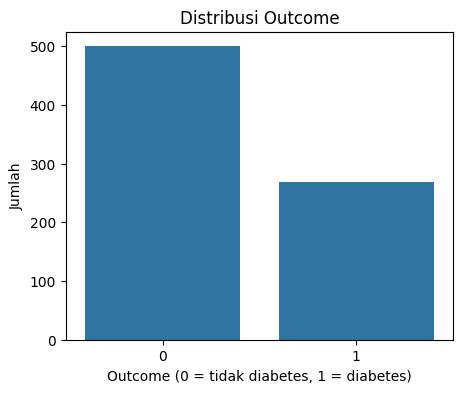

In [5]:
# liat perbandingan jumlah pasien diabetes (1) sama yang engga (0)
print(df['Outcome'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Outcome')
plt.xlabel('Outcome (0 = tidak diabetes, 1 = diabetes)')
plt.ylabel('Jumlah')
plt.show()

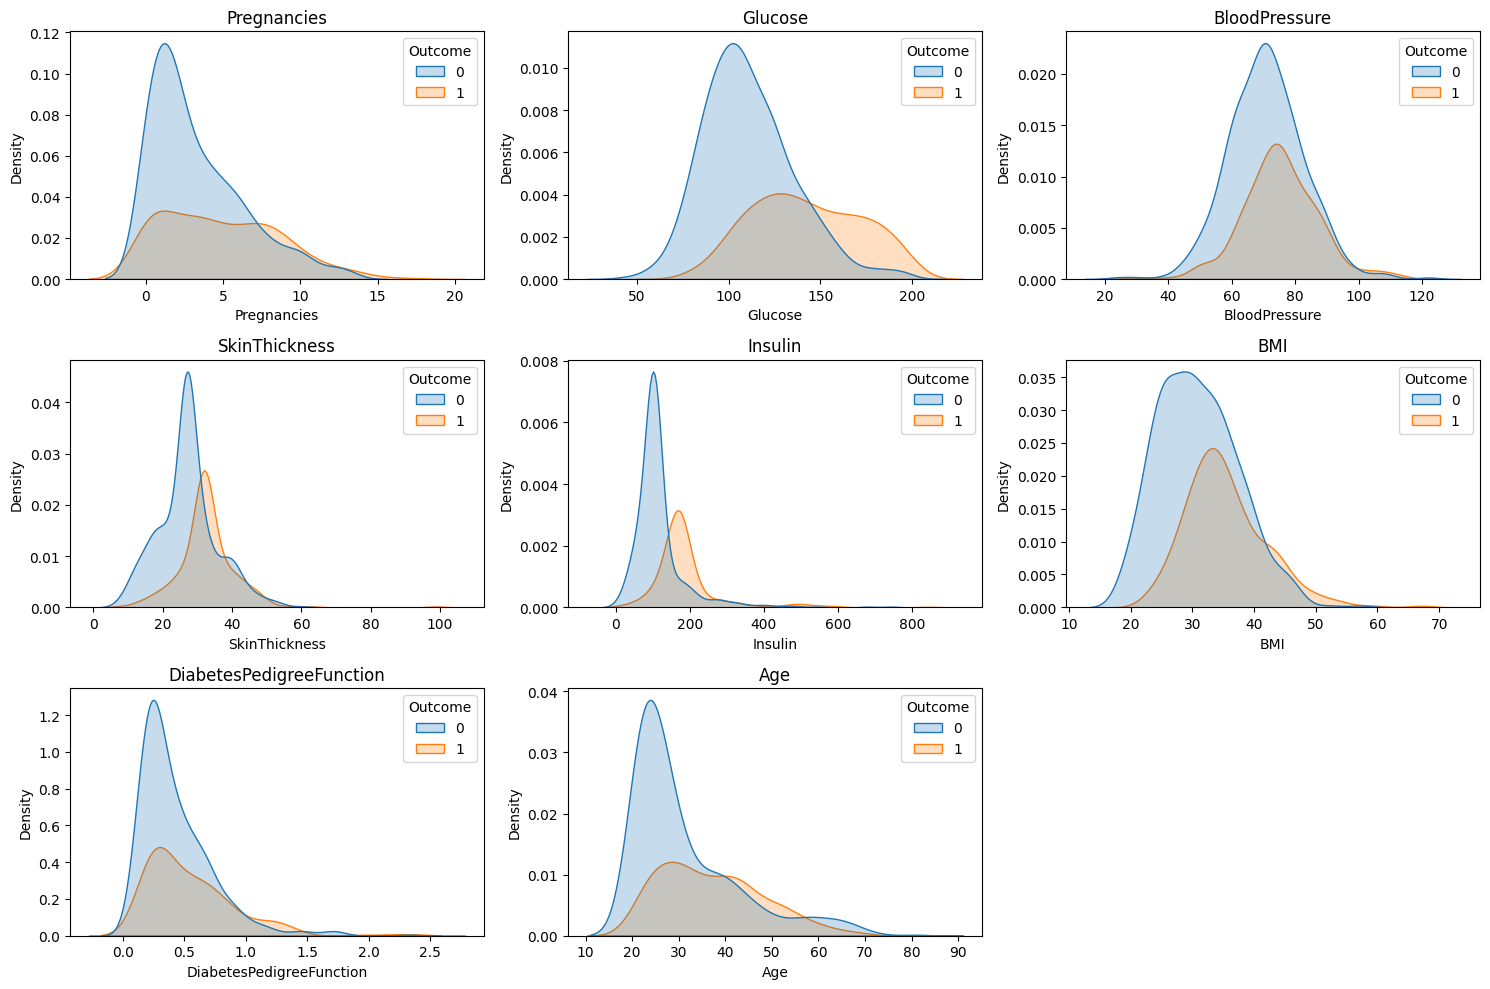

In [6]:
# liat sebaran tiap fitur, dipisah berdasarkan outcome nya
fitur = df.columns[:-1]

plt.figure(figsize=(15,10))
for i in range(len(fitur)):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=df, x=fitur[i], hue='Outcome', fill=True)
    plt.title(fitur[i])

plt.tight_layout()
plt.show()

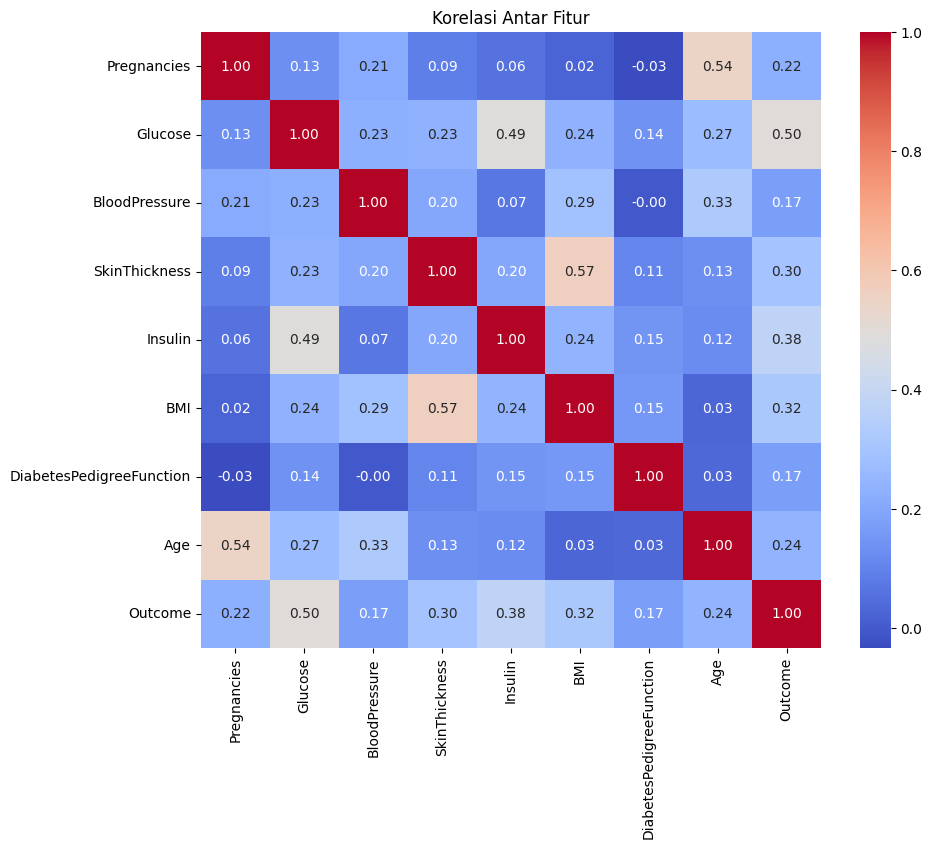

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.show()

#### Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

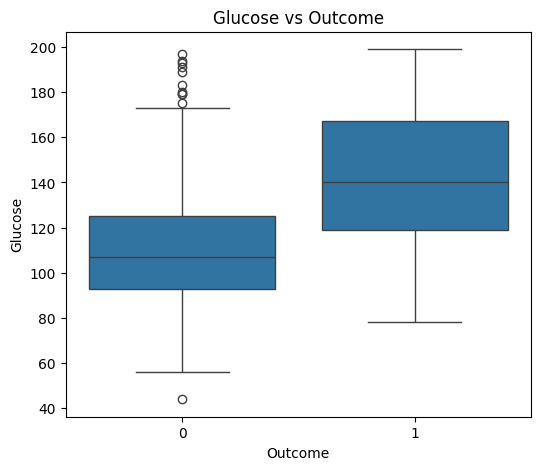

In [8]:
# menconba liat kadar glucose ngaruh apa engga ke outcome
plt.figure(figsize=(6,5))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose vs Outcome')
plt.show()

### 2. Preprocessing

In [9]:
# kolom-kolom ini secara medis ga mungkin nilainya 0, jadi kemungkinan itu missing value yang ditulis 0
kolom_cek = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in kolom_cek:
    jumlah_nol = (df[col] == 0).sum()
    print(col, ":", jumlah_nol, "nilai 0")

Glucose : 0 nilai 0
BloodPressure : 0 nilai 0
SkinThickness : 0 nilai 0
Insulin : 0 nilai 0
BMI : 0 nilai 0


In [10]:
# ganti nilai 0 nya jadi NaN dulu, biar nanti gampang diisi pake median
for col in kolom_cek:
    df[col] = df[col].replace(0, np.nan)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# split dulu sebelum imputasi biar median yang dipake buat isi missing value cuma dari data train
# jadi ga ada info dari data test yang kebocor ke proses ini
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("data train:", X_train.shape)
print("data test:", X_test.shape)

data train: (614, 8)
data test: (154, 8)


In [12]:
for col in kolom_cek:
    median_train = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_train)
    X_test[col] = X_test[col].fillna(median_train)

X_train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [13]:
# scaling biar semua fitur punya skala seimbang, soalnya rentang nilai tiap kolom beda-beda jauh
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-0.85135507 -1.0568694  -0.82668697 -1.8952899  -1.17037761 -0.76615019
   0.31079384 -0.79216928]
 [ 0.35657564  0.1428554   0.4770088  -0.22473578 -1.42764161 -0.41444809
  -0.11643851  0.56103382]
 [-0.5493724  -0.55698407 -1.15261091  1.22307779 -0.54559361  0.36222739
  -0.76486207 -0.70759409]
 [-0.85135507  0.80936917 -1.31557289 -0.22473578 -0.44146295 -0.39979383
   0.26231357 -0.36929331]
 [-1.15333775 -0.89024096 -0.663725    1.11170751 -0.41083628  1.78369005
  -0.33762972 -0.96131967]]


### 3. Eksperimen Model

#### 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [14]:
# GaussianNB dipake karena semua fitur di dataset ini numerik kontinu
model_gnb = GaussianNB()
model_gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [15]:
pred_gnb = model_gnb.predict(X_test_scaled)
prob_gnb = model_gnb.predict_proba(X_test_scaled)[:, 1]

print(pred_gnb[:10])

[0 0 0 0 0 0 1 1 0 1]


#### 3.2 Logistic Regression

In [16]:
model_log = LogisticRegression()
model_log.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [17]:
pred_log = model_log.predict(X_test_scaled)
prob_log = model_log.predict_proba(X_test_scaled)[:, 1]

print(pred_log[:10])

[0 0 0 0 0 0 1 1 0 1]


### 4. Evaluasi Model

In [18]:
acc_gnb = accuracy_score(y_test, pred_gnb)
prec_gnb = precision_score(y_test, pred_gnb)
rec_gnb = recall_score(y_test, pred_gnb)
f1_gnb = f1_score(y_test, pred_gnb)

acc_log = accuracy_score(y_test, pred_log)
prec_log = precision_score(y_test, pred_log)
rec_log = recall_score(y_test, pred_log)
f1_log = f1_score(y_test, pred_log)

data_hasil = {
    'Model': ['Gaussian NB', 'Logistic Regression'],
    'Accuracy': [acc_gnb, acc_log],
    'Precision': [prec_gnb, prec_log],
    'Recall': [rec_gnb, rec_log],
    'F1-Score': [f1_gnb, f1_log]
}

df_hasil = pd.DataFrame(data_hasil)
df_hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


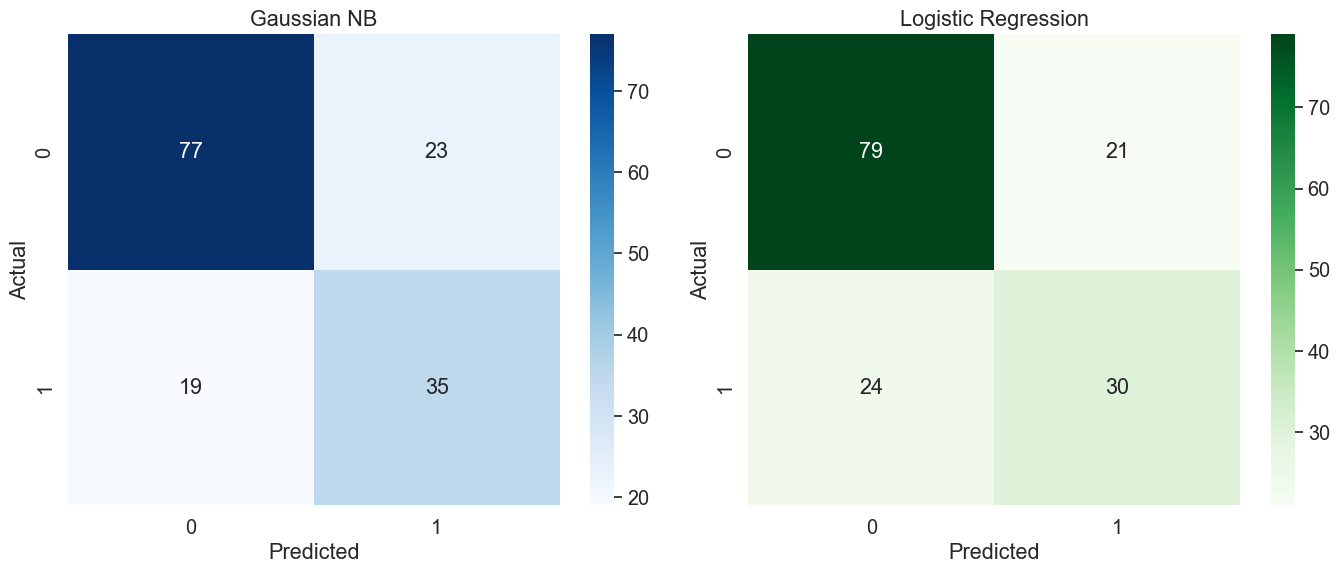

In [19]:
sns.set(font_scale=1.3)

cm_gnb = confusion_matrix(y_test, pred_gnb)
cm_log = confusion_matrix(y_test, pred_log)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Gaussian NB')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

sns.set(font_scale=1)

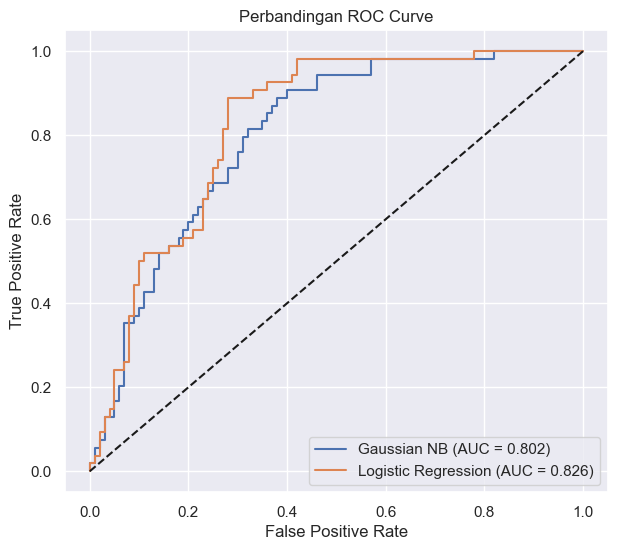

In [20]:
fpr_gnb, tpr_gnb, thresh1 = roc_curve(y_test, prob_gnb)
fpr_log, tpr_log, thresh2 = roc_curve(y_test, prob_log)

auc_gnb = auc(fpr_gnb, tpr_gnb)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(7,6))
plt.plot(fpr_gnb, tpr_gnb, label='Gaussian NB (AUC = ' + str(round(auc_gnb,3)) + ')')
plt.plot(fpr_log, tpr_log, label='Logistic Regression (AUC = ' + str(round(auc_log,3)) + ')')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Perbandingan ROC Curve')
plt.legend()
plt.show()

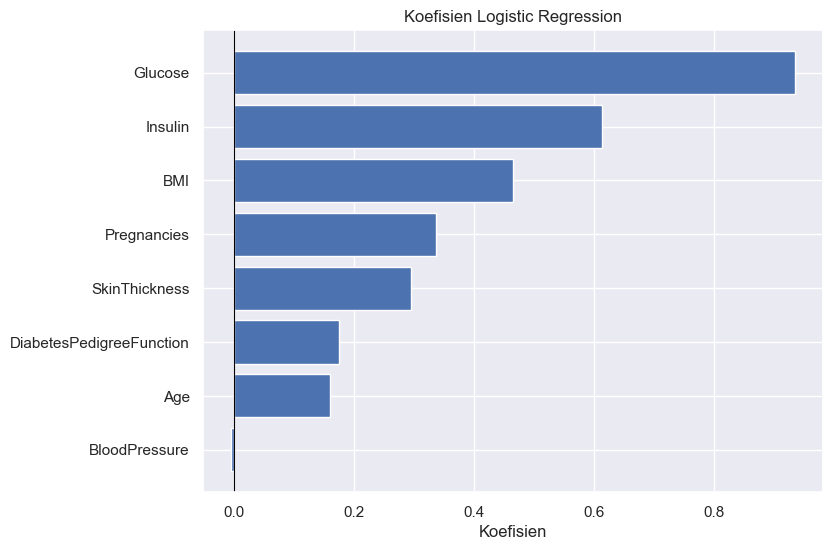

In [21]:
# liat koefisien tiap fitur di logistic regression
# koefisien positif artinya fitur itu nambah kemungkinan diabetes, negatif sebaliknya
koef = model_log.coef_[0]
nama_fitur = X.columns

df_koef = pd.DataFrame({'Fitur': nama_fitur, 'Koefisien': koef})
df_koef = df_koef.sort_values('Koefisien')

plt.figure(figsize=(8,6))
plt.barh(df_koef['Fitur'], df_koef['Koefisien'])
plt.xlabel('Koefisien')
plt.title('Koefisien Logistic Regression')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()

### 5. Analisis

Dari hasil eksperimen, ini perbandingan performa kedua model:

| Model | Accuracy | Precision | Recall | F1-Score | AUC |
|---|---|---|---|---|---|
| Gaussian NB | 0.7273 | 0.6034 | 0.6481 | 0.6252 | 0.802 |
| Logistic Regression | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.826 |

Menariknya di sini hasilnya nggak sesimpel itu, satu model menang telak di semua metrik. Gaussian NB unggul di accuracy, precision, recall, sama f1-score, tapi logistic regression malah unggul di AUC. Ini kelihatan juga dari confusion matrix-nya, Gaussian NB berhasil nangkep lebih banyak pasien diabetes (TP=35) dibanding logistic regression (TP=30), meski dua-duanya masih banyak yang kelewat (FN 19 vs 24).

Kalo dilihat dari cara kerja modelnya, ini masuk akal. GaussianNB ngasumsiin tiap fitur berdistribusi normal dan independen satu sama lain, terus ngitung probabilitas berdasarkan itu semua. Sementara logistic regression nyari garis pemisah linear dari kombinasi semua fitur sekaligus. Dari heatmap korelasi yang udah dibuat sebelumnya, ada beberapa fitur yang saling berkorelasi lumayan tinggi kayak SkinThickness sama BMI (0.57) atau Glucose sama Insulin (0.49). Nah asumsi independensi di Naive Bayes ini sebenernya dilanggar sama korelasi-korelasi itu, tapi anehnya performanya malah tetep lebih bagus di metrik-metrik yang dilihat sekarang.

AUC yang lebih tinggi di logistic regression (0.826 vs 0.802) nunjukkin bahwa secara keseluruhan across semua threshold, LR punya kemampuan yang lebih konsisten buat misahin kelas 0 sama 1. Tapi pas udah masuk ke threshold default (0.5), performanya malah kalah dibanding GNB. Ini bisa jadi karena distribusi probabilitas yang dihasilkan LR belum tentu optimal di titik 0.5, jadi ada kemungkinan performanya bisa lebih bagus lagi kalo threshold-nya diatur ulang.

Kalo diliat dari bar chart koefisien logistic regression, Glucose jadi fitur yang paling berpengaruh buat nentuin diabetes, disusul Insulin dan BMI. Ini sejalan juga sama hasil heatmap korelasi di awal, di mana Glucose emang punya korelasi paling tinggi ke Outcome (0.50). Fitur BloodPressure koefisiennya hampir 0, artinya kontribusinya ke prediksi model kecil banget, konsisten juga sama korelasinya ke Outcome yang paling rendah di antara semua fitur (0.17).

Dari sisi recall, dua-duanya masih terbilang kurang, cuma di kisaran 55-65%. Artinya masih banyak pasien yang sebenernya diabetes tapi ketebak engga. Dalam konteks medis, ini cukup riskan karena pasien yang harusnya dapet penanganan lebih awal malah nggak kedeteksi.

### 6. Kesimpulan dan Saran

Dari eksperimen ini, Gaussian NB unggul di accuracy, precision, recall, dan f1-score, sementara logistic regression unggul di AUC. Jadi nggak bisa dibilang salah satu model pasti lebih baik dari yang lain secara mutlak, tergantung metrik apa yang mau diprioritaskan. Kalo fokusnya ke jumlah prediksi bener secara keseluruhan di threshold default, Gaussian NB lebih unggul. Tapi kalo yang dipentingin kemampuan misahin kelas secara umum, logistic regression lebih baik.

Recall di kedua model masih terbilang rendah (55-65%), jadi masih banyak kasus diabetes yang kelewat kedeteksi. Ini jadi concern utama karena di kasus medis kayak gini, kesalahan tipe FN (pasien diabetes tapi ketebak sehat) jauh lebih berisiko dibanding FP.

Saran buat eksperimen selanjutnya:
1. Coba threshold tuning, khususnya buat logistic regression yang AUC nya udah bagus tapi performa di threshold 0.5 belum optimal, siapa tau geser threshold bisa naikin recall tanpa ngorbanin precision terlalu banyak.
2. Coba tangani ketidakseimbangan kelas, soalnya distribusi Outcome di dataset ini lumayan timpang (500 pasien tidak diabetes vs 268 diabetes), bisa pake teknik kayak SMOTE atau class_weight biar model lebih peka ke kelas minoritas.
3. Untuk Gaussian NB, mengingat asumsi independensi antar fitur dilanggar sama beberapa fitur yang berkorelasi tinggi (SkinThickness-BMI, Glucose-Insulin), bisa dicoba drop salah satu fitur yang redundant atau pake model lain yang ga butuh asumsi independensi kayak Random Forest.

Itu aja mungkin untuk kesimpulan dan saran dari eksperimen ini.